## Import librairies

In [65]:
%matplotlib inline

from time import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import metrics
from sklearn.cluster import KMeans
from sklearn.datasets import make_classification, load_digits
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from yellowbrick.cluster import InterclusterDistance, SilhouetteVisualizer, KElbowVisualizer


pd.set_option("display.max_columns", None)

## Load the dataset

We will start by loading the digits dataset. This dataset contains handwritten digits from 0 to 9. In the context of clustering, one would like to group images such that the handwritten digits on the image are the same.

In [66]:
digits = load_digits()  # Dimensionality: 64 features

X, labels = digits.data, digits.target
images = digits.images

# column name for 64
column_names = [f"X{i}" for i in range(64)]

data = pd.DataFrame(X, columns=column_names).assign(label=labels)

(n_samples, n_features), n_digits = X.shape, np.unique(labels).size

print(f"# digits: {n_digits}; # samples: {n_samples}; # features {n_features}")

# digits: 10; # samples: 1797; # features 64


In [67]:
data.head()

,X0,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,X24,X25,X26,X27,X28,X29,X30,X31,X32,X33,X34,X35,X36,X37,X38,X39,X40,X41,X42,X43,X44,X45,X46,X47,X48,X49,X50,X51,X52,X53,X54,X55,X56,X57,X58,X59,X60,X61,X62,X63,label
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,13.0,15.0,10.0,15.0,5.0,0.0,0.0,3.0,15.0,2.0,0.0,11.0,8.0,0.0,0.0,4.0,12.0,0.0,0.0,8.0,8.0,0.0,0.0,5.0,8.0,0.0,0.0,9.0,8.0,0.0,0.0,4.0,11.0,0.0,1.0,12.0,7.0,0.0,0.0,2.0,14.0,5.0,10.0,12.0,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,0.0,11.0,16.0,9.0,0.0,0.0,0.0,0.0,3.0,15.0,16.0,6.0,0.0,0.0,0.0,7.0,15.0,16.0,16.0,2.0,0.0,0.0,0.0,0.0,1.0,16.0,16.0,3.0,0.0,0.0,0.0,0.0,1.0,16.0,16.0,6.0,0.0,0.0,0.0,0.0,1.0,16.0,16.0,6.0,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,3.0,16.0,15.0,14.0,0.0,0.0,0.0,0.0,8.0,13.0,8.0,16.0,0.0,0.0,0.0,0.0,1.0,6.0,15.0,11.0,0.0,0.0,0.0,1.0,8.0,13.0,15.0,1.0,0.0,0.0,0.0,9.0,16.0,16.0,5.0,0.0,0.0,0.0,0.0,3.0,13.0,16.0,16.0,11.0,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,13.0,6.0,15.0,4.0,0.0,0.0,0.0,2.0,1.0,13.0,13.0,0.0,0.0,0.0,0.0,0.0,2.0,15.0,11.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,12.0,12.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,10.0,8.0,0.0,0.0,0.0,8.0,4.0,5.0,14.0,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,8.0,0.0,0.0,0.0,0.0,0.0,1.0,13.0,6.0,2.0,2.0,0.0,0.0,0.0,7.0,15.0,0.0,9.0,8.0,0.0,0.0,5.0,16.0,10.0,0.0,16.0,6.0,0.0,0.0,4.0,15.0,16.0,13.0,16.0,1.0,0.0,0.0,0.0,0.0,3.0,15.0,10.0,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


## EDA

C:\Users\MBAYE\AppData\Local\Temp\ipykernel_10692\3374211802.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=data, palette='tab10')


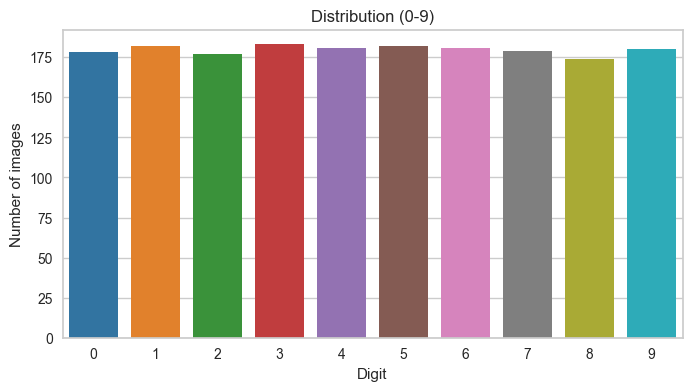

In [68]:
plt.figure(figsize=(8, 4))
sns.countplot(x='label', data=data, palette='tab10')

plt.title("Distribution (0-9)")
plt.xlabel("Digit")
plt.ylabel("Number of images")
plt.show()

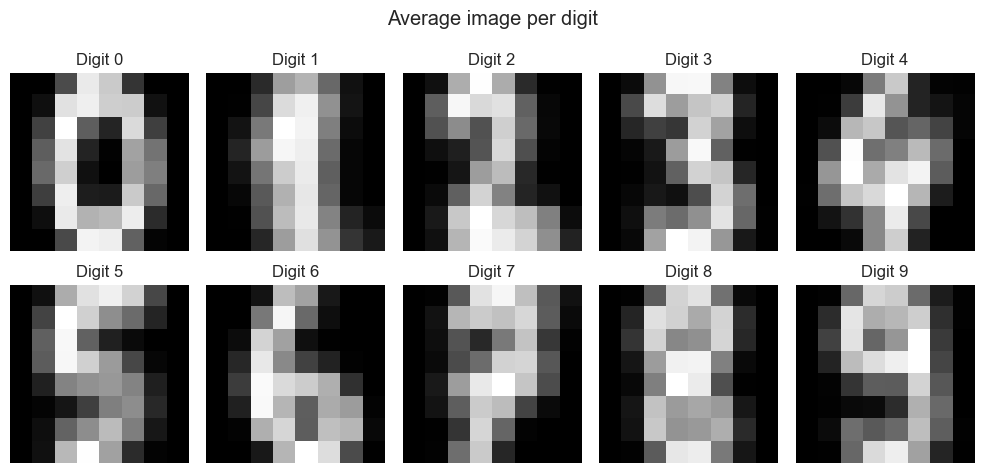

In [69]:
# mean by digit
mean_images = np.zeros((10, 64))  # 64 pixels
for i in range(10):
    mean_images[i] = data.loc[data.label == i, column_names].mean(axis=0)


fig, axs = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axs.flat):
    ax.imshow(mean_images[i].reshape(8, 8), cmap='gray')
    ax.set_title(f"Digit {i}")
    ax.axis('off')
plt.suptitle("Average image per digit")
plt.tight_layout()
plt.show()

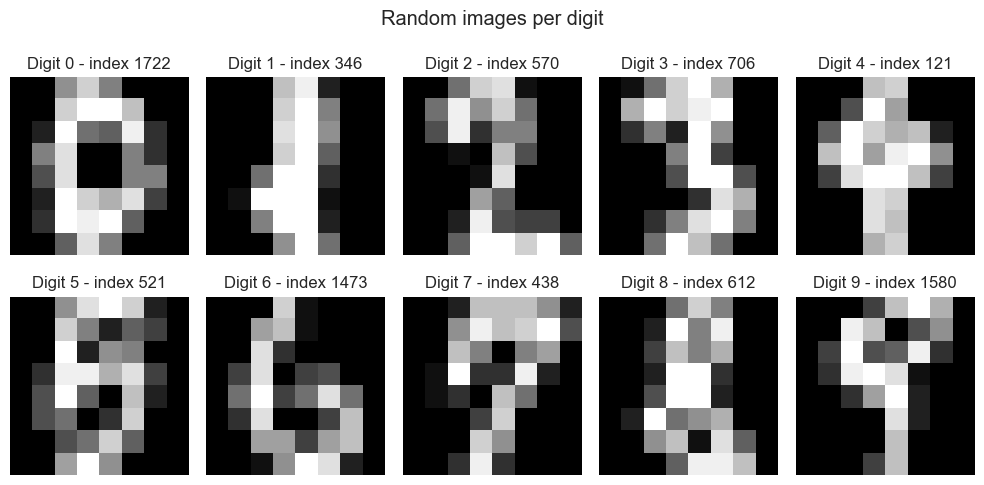

In [70]:
fig, axs = plt.subplots(2, 5, figsize=(10, 5))
plt.subplots_adjust(left=0.01, right=0.99, bottom=0.01, top=0.91, hspace=0.5)

for i, label in enumerate(np.unique(labels)):
    ax = axs[i // 5, i % 5]
    # Random choice by digit
    idx = np.random.choice(np.where(labels == label)[0])
    ax.imshow(images[idx], cmap='gray')
    ax.set_title(f"Digit {label} - index {idx}")
    ax.axis('off')

plt.suptitle("Random images per digit")
plt.tight_layout()
plt.show();

## Define our evaluation benchmark

We will first our evaluation benchmark. During this benchmark, we intend to compare different initialization methods for KMeans. Our benchmark will:

create a pipeline which will scale the data using a StandardScaler;

train and time the pipeline fitting;

measure the performance of the clustering obtained via different metrics.


In [71]:
def bench_k_means(kmeans, name, data, labels):
    """Benchmark to evaluate the KMeans initialization methods.

    Parameters
    ----------
    kmeans : KMeans instance
        A :class:`~sklearn.cluster.KMeans` instance with the initialization
        already set.
    name : str
        Name given to the strategy. It will be used to show the results in a
        table.
    data : ndarray of shape (n_samples, n_features)
        The data to cluster.
    labels : ndarray of shape (n_samples,)
        The labels used to compute the clustering metrics which requires some
        supervision.
    """
    t0 = time()
    estimator = make_pipeline(MinMaxScaler(), kmeans).fit(data)
    fit_time = time() - t0
    results = [name, fit_time, estimator[-1].inertia_]

    # Define the metrics which require only the true labels and estimator
    # labels
    clustering_metrics = [
        metrics.homogeneity_score,
        metrics.completeness_score,
        metrics.v_measure_score,
        metrics.adjusted_rand_score,
    ]
    results += [m(labels, estimator[-1].labels_) for m in clustering_metrics]

    # The silhouette score requires the full dataset
    results += [
        metrics.silhouette_score(
            data,
            estimator[-1].labels_,
            metric="euclidean",
            sample_size=300,
        )
    ]
    

    # Show the results
    formatter_result = (
        "{:9s}\t{:.3f}s\t{:.0f}\t{:.3f}\t{:.3f}\t{:.3f}\t{:.3f}\t{:.3f}"
    )
    print(formatter_result.format(*results))

### Run benchmark

In [72]:
print(82 * "_")
print("init\t\ttime\tinertia\thomo\tcompl\tv-meas\tARI\tsilhouette")

kmeans = KMeans(init="k-means++", n_clusters=n_digits, n_init=4, random_state=0)
bench_k_means(kmeans=kmeans, name="k-means++", data=X, labels=labels)

kmeans = KMeans(init="random", n_clusters=n_digits, n_init=4, random_state=0)
bench_k_means(kmeans=kmeans, name="random", data=X, labels=labels)

pca = PCA(n_components=n_digits).fit(X)
kmeans = KMeans(init=pca.components_, n_clusters=n_digits, n_init=1)
bench_k_means(kmeans=kmeans, name="PCA-based", data=X, labels=labels)

print(82 * "_")

__________________________________________________________________________________
init		time	inertia	homo	compl	v-meas	ARI	silhouette
k-means++	0.154s	4647	0.739	0.747	0.743	0.669	0.174
random   	0.067s	4648	0.735	0.742	0.738	0.667	0.180
PCA-based	0.036s	4647	0.744	0.753	0.749	0.673	0.176
__________________________________________________________________________________


## Optimal number of clusters

In [73]:
scaler = MinMaxScaler()  # StandardScaler()
X_scaled = scaler.fit_transform(X)

### Elbow method

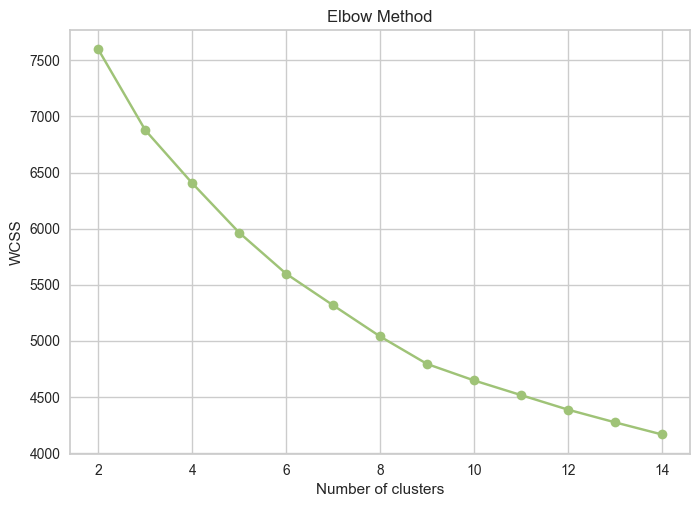

In [74]:
wcss = []  # Within-Cluster Sum of Squares 

k_grid = range(2, 15)
for i in k_grid:
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(k_grid, wcss, 'go-')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

### Yellow brick lib

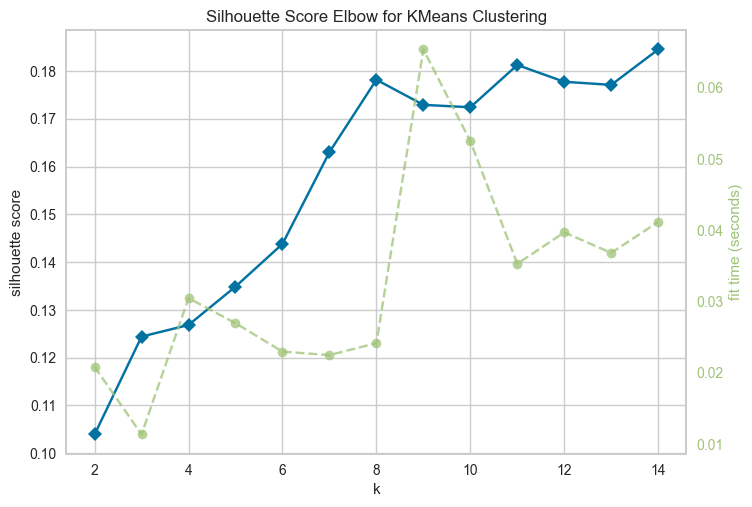

In [75]:
# Instantiate the clustering model and visualizer

# - **distortion**: mean sum of squared distances to centers
# - **silhouette**: mean ratio of intra-cluster and nearest-cluster distance
# - **calinski_harabasz**: ratio of within to between cluster dispersion

        
visualizer = KElbowVisualizer(KMeans(),
                              metric='silhouette',  # possible values: calinski_harabasz, distortion, silhouette
                              distance_metric="euclidean", # options allowed by sklearn's metrics.pairwise.pairwise_distances
                              k=k_grid,
                              timings=True,
                              locate_elbow=False, # True or False
                             )

visualizer.fit(X_scaled)        # Fit the data to the visualizer
visualizer.show();       # Finalize and render the figure

## Visualize the results on PCA-reduced data


### Profiling: cluster persona

In [76]:
reduced_data = PCA(n_components=2).fit_transform(X)
kmeans = KMeans(init="k-means++", n_clusters=n_digits, n_init=4)
kmeans.fit(reduced_data)

kmean_labels = kmeans.labels_

In [77]:
data["cluster"] = kmean_labels
data.head()

,X0,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,X24,X25,X26,X27,X28,X29,X30,X31,X32,X33,X34,X35,X36,X37,X38,X39,X40,X41,X42,X43,X44,X45,X46,X47,X48,X49,X50,X51,X52,X53,X54,X55,X56,X57,X58,X59,X60,X61,X62,X63,label,cluster
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,13.0,15.0,10.0,15.0,5.0,0.0,0.0,3.0,15.0,2.0,0.0,11.0,8.0,0.0,0.0,4.0,12.0,0.0,0.0,8.0,8.0,0.0,0.0,5.0,8.0,0.0,0.0,9.0,8.0,0.0,0.0,4.0,11.0,0.0,1.0,12.0,7.0,0.0,0.0,2.0,14.0,5.0,10.0,12.0,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0,7
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,0.0,11.0,16.0,9.0,0.0,0.0,0.0,0.0,3.0,15.0,16.0,6.0,0.0,0.0,0.0,7.0,15.0,16.0,16.0,2.0,0.0,0.0,0.0,0.0,1.0,16.0,16.0,3.0,0.0,0.0,0.0,0.0,1.0,16.0,16.0,6.0,0.0,0.0,0.0,0.0,1.0,16.0,16.0,6.0,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1,9
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,3.0,16.0,15.0,14.0,0.0,0.0,0.0,0.0,8.0,13.0,8.0,16.0,0.0,0.0,0.0,0.0,1.0,6.0,15.0,11.0,0.0,0.0,0.0,1.0,8.0,13.0,15.0,1.0,0.0,0.0,0.0,9.0,16.0,16.0,5.0,0.0,0.0,0.0,0.0,3.0,13.0,16.0,16.0,11.0,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2,4
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,13.0,6.0,15.0,4.0,0.0,0.0,0.0,2.0,1.0,13.0,13.0,0.0,0.0,0.0,0.0,0.0,2.0,15.0,11.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,12.0,12.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,10.0,8.0,0.0,0.0,0.0,8.0,4.0,5.0,14.0,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3,5
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,8.0,0.0,0.0,0.0,0.0,0.0,1.0,13.0,6.0,2.0,2.0,0.0,0.0,0.0,7.0,15.0,0.0,9.0,8.0,0.0,0.0,5.0,16.0,10.0,0.0,16.0,6.0,0.0,0.0,4.0,15.0,16.0,13.0,16.0,1.0,0.0,0.0,0.0,0.0,3.0,15.0,10.0,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4,1


In [78]:
# Mapping cluster => label
contingency_table = pd.crosstab(data["cluster"], data["label"])
contingency_table

label,0,1,2,3,4,5,6,7,8,9
cluster,,,,,,,,,,
0,1,28,36,10,0,44,0,1,71,16
1,1,4,0,0,144,2,21,1,1,0
2,4,7,4,21,0,49,0,0,10,78
3,0,0,113,49,0,4,0,0,3,9
4,0,47,12,0,5,47,2,39,61,10
5,0,0,0,90,0,0,0,0,0,57
6,0,9,12,13,3,26,0,117,24,9
7,160,0,0,0,0,5,8,0,0,0
8,12,0,0,0,24,5,150,0,0,1


In [79]:
major_digit = contingency_table.idxmax(axis=1)
print(major_digit)

cluster
0    8
1    4
2    9
3    2
4    8
5    3
6    7
7    0
8    6
9    1
dtype: int64


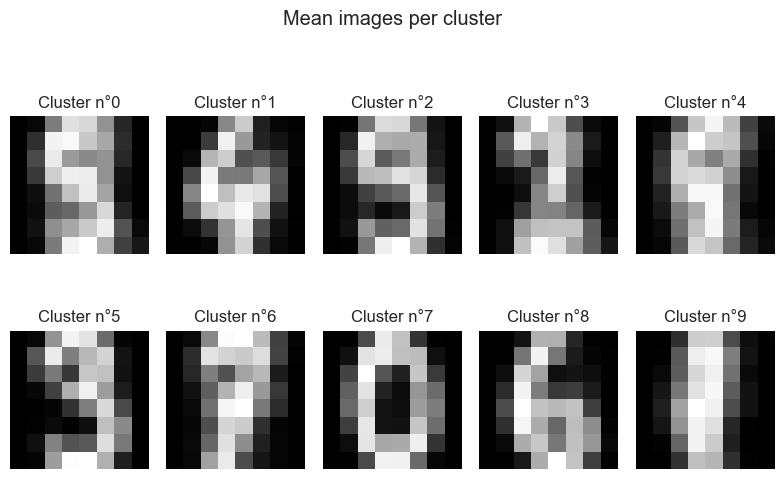

In [80]:
for cluster_id in range(n_digits):
    cluster_indices = np.where(kmean_labels == cluster_id)
    cluster_images = X[cluster_indices]
    mean_image = cluster_images.mean(axis=0).reshape(8, 8)
    
    plt.subplot(2, 5, cluster_id + 1)
    plt.imshow(mean_image, cmap='gray')
    plt.title(f"Cluster n°{cluster_id}")
    plt.axis('off')
    
plt.suptitle("Mean images per cluster")
plt.tight_layout()
plt.show()

### Visualization

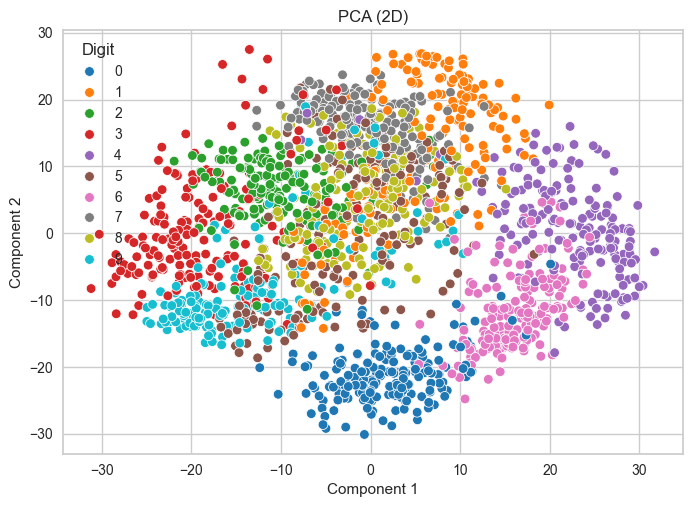

In [81]:
sns.scatterplot(x=reduced_data[:, 0], y=reduced_data[:, 1], hue=data.label, palette='tab10', legend='full')
plt.title("PCA (2D)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend(title="Digit")
plt.show()


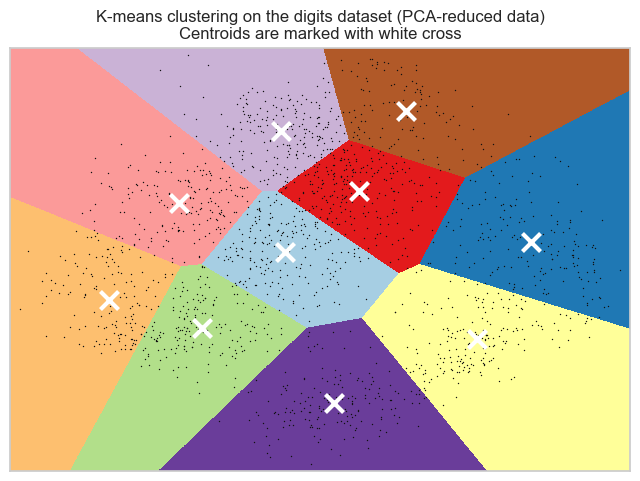

In [82]:


# Step size of the mesh. Decrease to increase the quality of the VQ.
h = 0.02  # point in the mesh [x_min, x_max]x[y_min, y_max].

# Plot the decision boundary. For that, we will assign a color to each
x_min, x_max = reduced_data[:, 0].min() - 1, reduced_data[:, 0].max() + 1
y_min, y_max = reduced_data[:, 1].min() - 1, reduced_data[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Obtain labels for each point in mesh. Use last trained model.
Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])

# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.figure(1)
plt.clf()
plt.imshow(
    Z,
    interpolation="nearest",
    extent=(xx.min(), xx.max(), yy.min(), yy.max()),
    cmap=plt.cm.Paired,
    aspect="auto",
    origin="lower",
)

plt.plot(reduced_data[:, 0], reduced_data[:, 1], "k.", markersize=2)
# Plot the centroids as a white X
centroids = kmeans.cluster_centers_
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="x",
    s=169,
    linewidths=3,
    color="w",
    zorder=10,
)
plt.title(
    "K-means clustering on the digits dataset (PCA-reduced data)\n"
    "Centroids are marked with white cross"
)
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.xticks(())
plt.yticks(());

## Intercluster Distance Maps

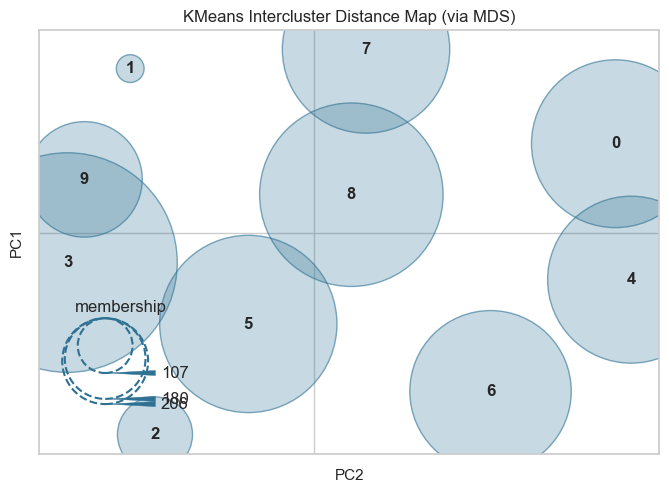

<Axes: title={'center': 'KMeans Intercluster Distance Map (via MDS)'}, xlabel='PC2', ylabel='PC1'>

In [83]:
# Instantiate the clustering model and visualizer
model = KMeans(10)
visualizer = InterclusterDistance(model)

visualizer.fit(X)        # Fit the data to the visualizer
visualizer.show()        # Finalize and render the figure

## Visualisation with TSNE

In [84]:
# Initialize
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)


### Optimiser k-means avec au moins 3 hyperparametres (nombre de clusters, etc)

L'optimisation de KMeans sur le jeu de données Digits a été réalisée en ajustant trois hyperparamètres : le nombre de clusters (5 à 12), la méthode d'initialisation (k-means++ ou random) et le nombre maximum d'itérations (300 ou 1000). Une standardisation des données et une réduction de dimension par PCA ont été testées pour améliorer les performances. La méthode du coude et le score de silhouette ont guidé la sélection du meilleur modèle. Les clusters ont été visualisés avec t-SNE pour interpréter les résultats.

# digits: 10; # samples: 1797; # features: 64

Résultats des combinaisons d'hyperparamètres :
    n_clusters       init  max_iter       inertia  silhouette_score
26          11     random       300  67304.527549          0.148644
27          11     random      1000  67304.527549          0.148644
24          11  k-means++       300  67283.423677          0.148338
25          11  k-means++      1000  67283.423677          0.148338
22          10     random       300  70552.757011          0.138316


C:\Users\MBAYE\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\yellowbrick\utils\kneed.py:156: YellowbrickWarning: No 'knee' or 'elbow point' detected This could be due to bad clustering, no actual clusters being formed etc.
  warnings.warn(warning_message, YellowbrickWarning)
C:\Users\MBAYE\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\yellowbrick\cluster\elbow.py:374: YellowbrickWarning: No 'knee' or 'elbow' point detected, pass `locate_elbow=False` to remove the warning
  warnings.warn(warning_message, YellowbrickWarning)


KMeans(init='random', n_clusters=11, random_state=42)

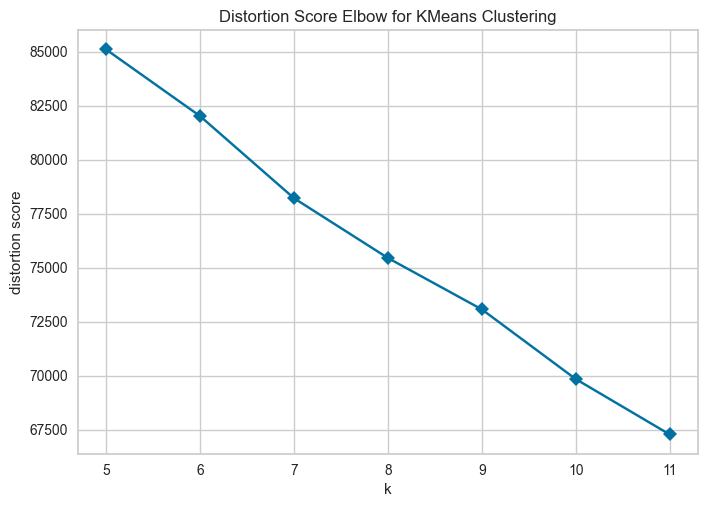

In [85]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from yellowbrick.cluster import KElbowVisualizer
import seaborn as sns
import itertools

# Charger le jeu de données Digits
digits = load_digits()
X, labels = digits.data, digits.target
n_samples, n_features = X.shape
n_digits = np.unique(labels).size
print(f"# digits: {n_digits}; # samples: {n_samples}; # features: {n_features}")

# Mise à l'échelle des données
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Définir les hyperparamètres à tester
n_clusters_range = range(5, 12)  # Tester de 5 à 12 clusters
init_methods = ['k-means++', 'random']
max_iter_values = [300, 1000]

# Stocker les résultats
results = []

# Tester toutes les combinaisons d'hyperparamètres
for n_clusters, init, max_iter in itertools.product(n_clusters_range, init_methods, max_iter_values):
    # Instancier et entraîner le modèle KMeans
    kmeans = KMeans(n_clusters=n_clusters, init=init, max_iter=max_iter, random_state=42)
    kmeans.fit(X_scaled)
    
    # Calculer le score de silhouette
    silhouette = silhouette_score(X_scaled, kmeans.labels_) if n_clusters > 1 else 0
    
    # Stocker les résultats
    results.append({
        'n_clusters': n_clusters,
        'init': init,
        'max_iter': max_iter,
        'inertia': kmeans.inertia_,
        'silhouette_score': silhouette
    })

# Convertir les résultats en DataFrame
results_df = pd.DataFrame(results)

# Afficher les résultats
print("\nRésultats des combinaisons d'hyperparamètres :")
print(results_df.sort_values(by='silhouette_score', ascending=False).head())

# Visualisation de la méthode du coude pour k-means++ et max_iter=300
model = KMeans(init='k-means++', max_iter=1000, random_state=42)
visualizer = KElbowVisualizer(model, k=(5, 12), metric='distortion', timings=False)
visualizer.fit(X_scaled)
visualizer.show(outpath="elbow_plot.png")

# Sélectionner la meilleure configuration (basée sur le score de silhouette)
best_config = results_df.loc[results_df['silhouette_score'].idxmax()]
best_kmeans = KMeans(
    n_clusters=int(best_config['n_clusters']),
    init=best_config['init'],
    max_iter=int(best_config['max_iter']),
    random_state=42
)
best_kmeans.fit(X_scaled)



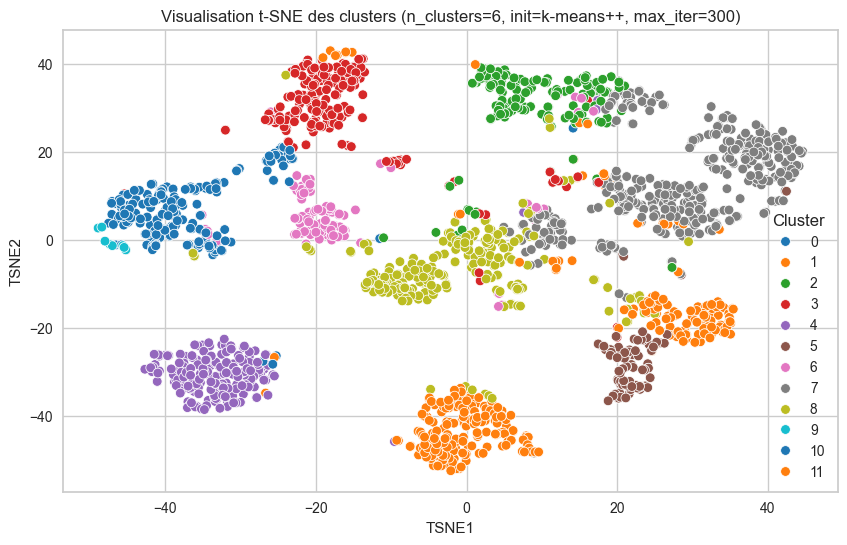


Meilleure configuration : n_clusters=6, init=k-means++, max_iter=300
Score de silhouette : 0.2323


In [98]:
# Visualisation t-SNE avec les clusters optimaux
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

# Créer un DataFrame pour la visualisation
tsne_df = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])
tsne_df['Cluster'] = best_kmeans.labels_
tsne_df['True Label'] = labels

# Visualisation des clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=tsne_df, x='TSNE1', y='TSNE2', hue='Cluster', palette='tab10',  legend='full')
plt.title(f'Visualisation t-SNE des clusters (n_clusters={best_config["n_clusters"]}, init={best_config["init"]}, max_iter={best_config["max_iter"]})')
plt.show()

# Afficher le score de silhouette pour la meilleure configuration
print(f"\nMeilleure configuration : n_clusters={best_config['n_clusters']}, init={best_config['init']}, max_iter={best_config['max_iter']}")
print(f"Score de silhouette : {best_config['silhouette_score']:.4f}")

### Tester l'optimisation avec ou sans réduction de dimension (Avec ou sans PCA)

L'optimisation de KMeans sur le jeu de données Digits a été effectuée avec et sans réduction de dimension par PCA (10 composantes), en ajustant le nombre de clusters (5 à 12), l'initialisation (k-means++ ou random) et le nombre maximum d'itérations (300 ou 1000). Les données ont été standardisées pour garantir des résultats robustes. La méthode du coude et le score de silhouette ont permis d'évaluer les performances des modèles. Les visualisations t-SNE ont facilité la comparaison des clusters avec et sans PCA.

In [87]:

# Charger le jeu de données Digits
digits = load_digits()
X, labels = digits.data, digits.target
n_samples, n_features = X.shape
n_digits = np.unique(labels).size
print(f"# digits: {n_digits}; # samples: {n_samples}; # features: {n_features}")

# Mise à l'échelle des données
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Appliquer PCA (10 composantes)
pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"Variance expliquée par 10 composantes PCA : {sum(pca.explained_variance_ratio_):.4f}")

# Définir les hyperparamètres à tester
n_clusters_range = range(5, 12)  # Tester de 5 à 15 clusters
init_methods = ['k-means++', 'random']
max_iter_values = [300, 1000]

# Fonction pour tester KMeans
def evaluate_kmeans(X_data, data_name):
    results = []
    for n_clusters, init, max_iter in itertools.product(n_clusters_range, init_methods, max_iter_values):
        kmeans = KMeans(n_clusters=n_clusters, init=init, max_iter=max_iter, random_state=42)
        kmeans.fit(X_data)
        silhouette = silhouette_score(X_data, kmeans.labels_) if n_clusters > 1 else 0
        results.append({
            'n_clusters': n_clusters,
            'init': init,
            'max_iter': max_iter,
            'inertia': kmeans.inertia_,
            'silhouette_score': silhouette,
            'data': data_name
        })
    return results

# Tester avec et sans PCA
results_no_pca = evaluate_kmeans(X_scaled, "Sans PCA")
results_pca = evaluate_kmeans(X_pca, "Avec PCA")

# Combiner les résultats
results_df = pd.DataFrame(results_no_pca + results_pca)



# digits: 10; # samples: 1797; # features: 64
Variance expliquée par 10 composantes PCA : 0.5887


In [88]:

# Afficher les meilleurs résultats
print("\nMeilleurs résultats (top 5 par score de silhouette) :")
print(results_df.sort_values(by='silhouette_score', ascending=False)[['data', 'n_clusters', 'init', 'max_iter', 'silhouette_score']].head())




Meilleurs résultats (top 5 par score de silhouette) :
        data  n_clusters       init  max_iter  silhouette_score
55  Avec PCA          11     random      1000          0.282824
54  Avec PCA          11     random       300          0.282824
49  Avec PCA          10  k-means++      1000          0.276437
48  Avec PCA          10  k-means++       300          0.276437
52  Avec PCA          11  k-means++       300          0.274264


C:\Users\MBAYE\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\yellowbrick\utils\kneed.py:156: YellowbrickWarning: No 'knee' or 'elbow point' detected This could be due to bad clustering, no actual clusters being formed etc.
  warnings.warn(warning_message, YellowbrickWarning)
C:\Users\MBAYE\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\yellowbrick\cluster\elbow.py:374: YellowbrickWarning: No 'knee' or 'elbow' point detected, pass `locate_elbow=False` to remove the warning
  warnings.warn(warning_message, YellowbrickWarning)


Text(0.5, 1.0, 'Méthode du coude (Avec PCA)')

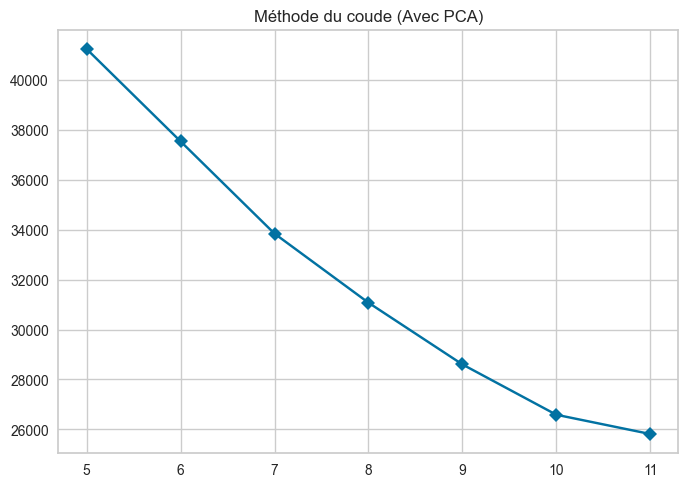

In [89]:
# Sélectionner les meilleures configurations
best_no_pca = results_df[results_df['data'] == "Sans PCA"].loc[results_df[results_df['data'] == "Sans PCA"]['silhouette_score'].idxmax()]
best_pca = results_df[results_df['data'] == "Avec PCA"].loc[results_df[results_df['data'] == "Avec PCA"]['silhouette_score'].idxmax()]

# Entraîner les meilleurs modèles
kmeans_no_pca = KMeans(
    n_clusters=int(best_no_pca['n_clusters']),
    init=best_no_pca['init'],
    max_iter=int(best_no_pca['max_iter']),
    random_state=42
)
kmeans_no_pca.fit(X_scaled)

kmeans_pca = KMeans(
    n_clusters=int(best_pca['n_clusters']),
    init=best_pca['init'],
    max_iter=int(best_pca['max_iter']),
    random_state=42
)
kmeans_pca.fit(X_pca)



# Avec PCA

model_pca = KMeans(init='k-means++', max_iter=300, random_state=42)
visualizer_pca = KElbowVisualizer(model_pca, k=(5, 12), metric='distortion', timings=False)
visualizer_pca.fit(X_pca)
plt.title("Méthode du coude (Avec PCA)")






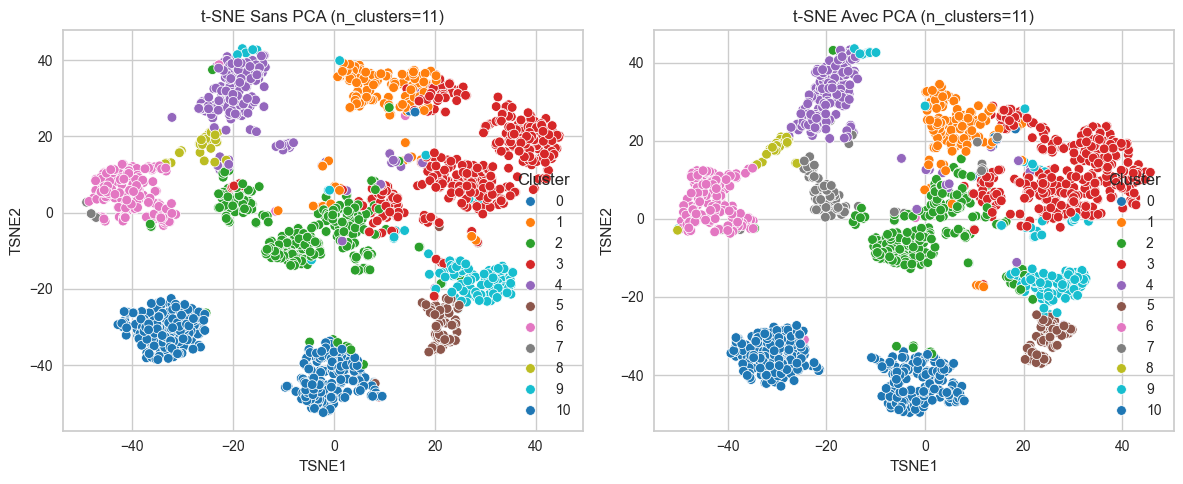

In [90]:
# Visualisation t-SNE (côte à côte)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)

# Sans PCA
X_tsne_no_pca = tsne.fit_transform(X_scaled)
tsne_df_no_pca = pd.DataFrame(X_tsne_no_pca, columns=['TSNE1', 'TSNE2'])
tsne_df_no_pca['Cluster'] = kmeans_no_pca.labels_
tsne_df_no_pca['True Label'] = labels

# Avec PCA
X_tsne_pca = tsne.fit_transform(X_pca)
tsne_df_pca = pd.DataFrame(X_tsne_pca, columns=['TSNE1', 'TSNE2'])
tsne_df_pca['Cluster'] = kmeans_pca.labels_
tsne_df_pca['True Label'] = labels

# Visualisation côte à côte
plt.figure(figsize=(12, 5))

# Sans PCA
plt.subplot(1, 2, 1)
sns.scatterplot(data=tsne_df_no_pca, x='TSNE1', y='TSNE2', hue='Cluster', palette='tab10',  legend='full')
plt.title(f"t-SNE Sans PCA (n_clusters={best_no_pca['n_clusters']})")

# Avec PCA
plt.subplot(1, 2, 2)
sns.scatterplot(data=tsne_df_pca, x='TSNE1', y='TSNE2', hue='Cluster', palette='tab10',  legend='full')
plt.title(f"t-SNE Avec PCA (n_clusters={best_pca['n_clusters']})")

plt.tight_layout()
plt.show()



In [91]:
# Afficher les résultats finaux
print("\nMeilleure configuration sans PCA :")
print(f"n_clusters={best_no_pca['n_clusters']}, init={best_no_pca['init']}, max_iter={best_no_pca['max_iter']}")
print(f"Score de silhouette : {best_no_pca['silhouette_score']:.4f}")

print("\nMeilleure configuration avec PCA :")
print(f"n_clusters={best_pca['n_clusters']}, init={best_pca['init']}, max_iter={best_pca['max_iter']}")
print(f"Score de silhouette : {best_pca['silhouette_score']:.4f}")


Meilleure configuration sans PCA :
n_clusters=11, init=random, max_iter=300
Score de silhouette : 0.1486

Meilleure configuration avec PCA :
n_clusters=11, init=random, max_iter=300
Score de silhouette : 0.2828


### Tester avec ou sans standardisation (Minmax, Standardscaller, Robustscaller)

L'optimisation de KMeans sur le jeu de données Digits a été réalisée avec PCA (10 composantes), en testant trois méthodes de standardisation (MinMaxScaler, StandardScaler, RobustScaler) et un cas sans standardisation. Les hyperparamètres ajustés incluent le nombre de clusters (5 à 12), l'initialisation (k-means++ ou random) et le nombre maximum d'itérations (300 ou 1000). La méthode du coude et le score de silhouette ont évalué la qualité des clusters. Les visualisations t-SNE et les courbes d'inertie ont permis de comparer l'impact des standardisations.

In [92]:
# Définir les méthodes de standardisation
scalers = {
    'Aucune': None,
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler()
}

# Définir les hyperparamètres à tester
n_clusters_range = range(5, 12)
init_methods = ['k-means++', 'random']
max_iter_values = [300, 1000]

# Fonction pour tester KMeans avec PCA
def evaluate_kmeans(X_data, scaler_name):
    results = []
    for n_clusters, init, max_iter in itertools.product(n_clusters_range, init_methods, max_iter_values):
        kmeans = KMeans(n_clusters=n_clusters, init=init, max_iter=max_iter, random_state=42)
        kmeans.fit(X_data)
        silhouette = silhouette_score(X_data, kmeans.labels_) if n_clusters > 1 else 0
        results.append({
            'n_clusters': n_clusters,
            'init': init,
            'max_iter': max_iter,
            'inertia': kmeans.inertia_,
            'silhouette_score': silhouette,
            'scaler': scaler_name
        })
    return results

# Tester toutes les standardisations avec PCA
results = []
for scaler_name, scaler in scalers.items():
    # Préparer les données
    X_processed = X if scaler is None else scaler.fit_transform(X)
    
    # Appliquer PCA
    pca = PCA(n_components=10, random_state=42)
    X_pca = pca.fit_transform(X_processed)
    print(f"Variance expliquée par 10 composantes PCA ({scaler_name}) : {sum(pca.explained_variance_ratio_):.4f}")
     # Tester KMeans
    results += evaluate_kmeans(X_pca, scaler_name)

# Convertir les résultats en DataFrame
results_df = pd.DataFrame(results)

# Afficher les meilleurs résultats
print("\nMeilleurs résultats avec PCA (top 5 par score de silhouette) :")
print(results_df.sort_values(by='silhouette_score', ascending=False)[['scaler', 'n_clusters', 'init', 'max_iter', 'silhouette_score']].head())



Variance expliquée par 10 composantes PCA (Aucune) : 0.7382
Variance expliquée par 10 composantes PCA (StandardScaler) : 0.5887
Variance expliquée par 10 composantes PCA (MinMaxScaler) : 0.7325
Variance expliquée par 10 composantes PCA (RobustScaler) : 0.7952

Meilleurs résultats avec PCA (top 5 par score de silhouette) :
            scaler  n_clusters       init  max_iter  silhouette_score
55  StandardScaler          11     random      1000          0.282824
54  StandardScaler          11     random       300          0.282824
49  StandardScaler          10  k-means++      1000          0.276437
48  StandardScaler          10  k-means++       300          0.276437
52  StandardScaler          11  k-means++       300          0.274264


Variance expliquée par 10 composantes PCA (Aucune) : 0.7382


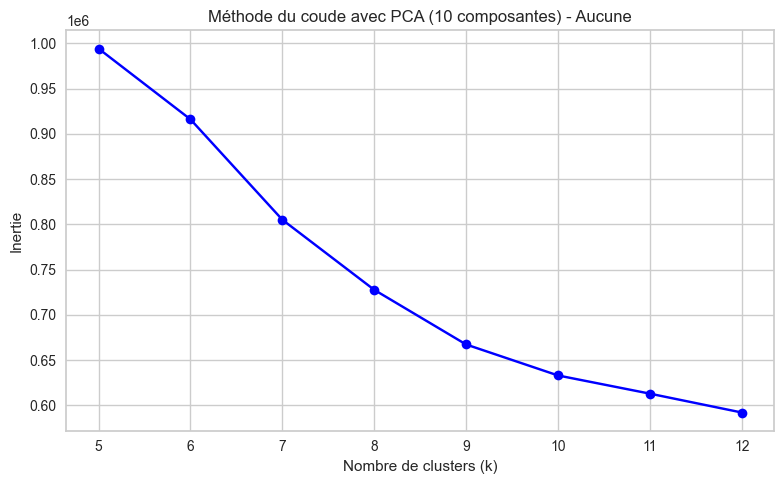

Variance expliquée par 10 composantes PCA (StandardScaler) : 0.5887
Variance expliquée par 10 composantes PCA (MinMaxScaler) : 0.7325
Variance expliquée par 10 composantes PCA (RobustScaler) : 0.7952


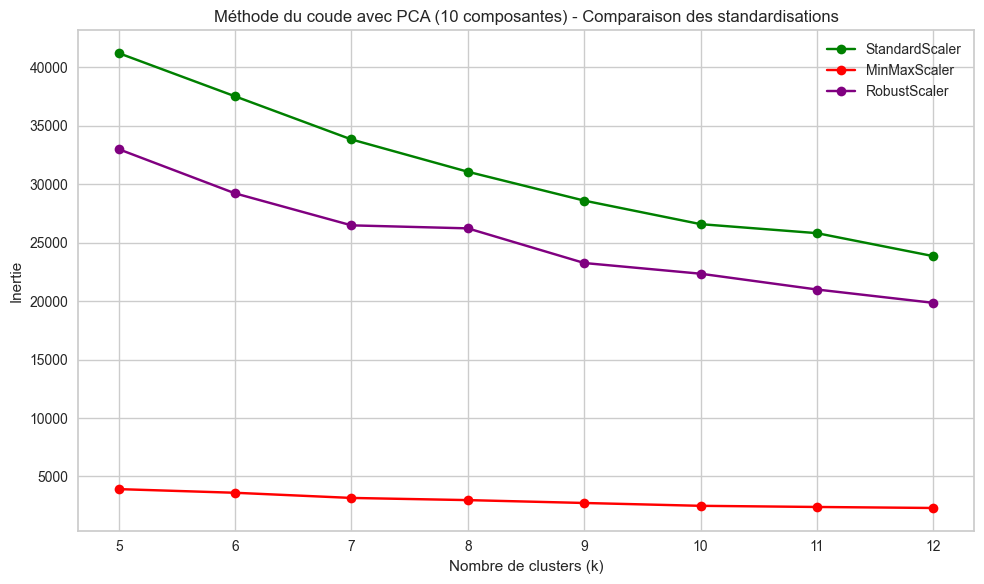

In [93]:
# Définir les méthodes de standardisation
scalers = {
    'Aucune': None,
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler()
}

# Paramètres
n_clusters_range = range(5, 13)  # 5 à 12 comme spécifié
colors = ['green', 'red', 'purple']  # Couleurs pour StandardScaler, MinMaxScaler, RobustScaler

# Graphique individuel pour "Aucune" standardisation
scaler_name = 'Aucune'
X_processed = X if scalers[scaler_name] is None else scalers[scaler_name].fit_transform(X)
pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X_processed)
print(f"Variance expliquée par 10 composantes PCA ({scaler_name}) : {sum(pca.explained_variance_ratio_):.4f}")

# Calculer l'inertie pour "Aucune"
inertias = []
for n_clusters in n_clusters_range:
    kmeans = KMeans(n_clusters=n_clusters, init='k-means++', max_iter=1000, random_state=42)
    kmeans.fit(X_pca)
    inertias.append(kmeans.inertia_)

# Créer le graphique individuel
plt.figure(figsize=(8, 5))
plt.plot(n_clusters_range, inertias, marker='o', color='blue')
plt.title(f"Méthode du coude avec PCA (10 composantes) - {scaler_name}")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie")
plt.grid(True)
plt.tight_layout()
plt.savefig('elbow_pca_none.png')
plt.show()

# Graphique combiné pour StandardScaler, MinMaxScaler, RobustScaler
plt.figure(figsize=(10, 6))
for scaler_name, color in zip(['StandardScaler', 'MinMaxScaler', 'RobustScaler'], colors):
    X_processed = X if scalers[scaler_name] is None else scalers[scaler_name].fit_transform(X)
    pca = PCA(n_components=10, random_state=42)
    X_pca = pca.fit_transform(X_processed)
    print(f"Variance expliquée par 10 composantes PCA ({scaler_name}) : {sum(pca.explained_variance_ratio_):.4f}")
    
    # Calculer l'inertie
    inertias = []
    for n_clusters in n_clusters_range:
        kmeans = KMeans(n_clusters=n_clusters, init='k-means++', max_iter=1000, random_state=42)
        kmeans.fit(X_pca)
        inertias.append(kmeans.inertia_)
    
    # Tracer la courbe
    plt.plot(n_clusters_range, inertias, marker='o', color=color, label=scaler_name)

# Personnaliser le graphique combiné
plt.title("Méthode du coude avec PCA (10 composantes) - Comparaison des standardisations")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('elbow_pca_combined.png')
plt.show()

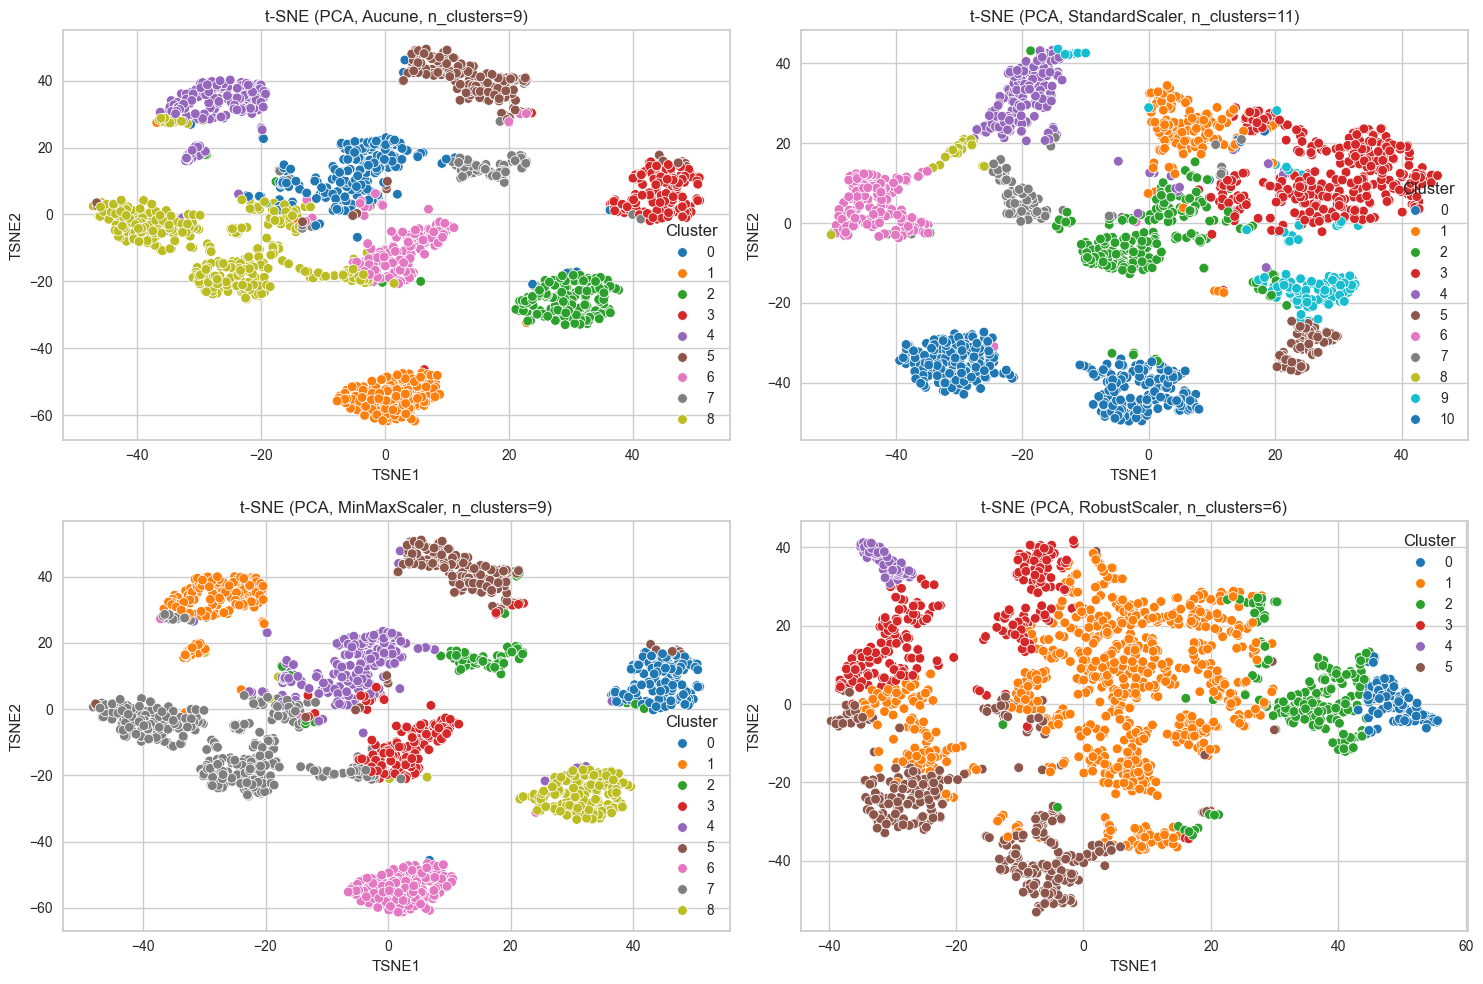


Meilleures configurations avec PCA :

Aucune :
n_clusters=9, init=random, max_iter=300
Score de silhouette : 0.2708

StandardScaler :
n_clusters=11, init=random, max_iter=300
Score de silhouette : 0.2828

MinMaxScaler :
n_clusters=9, init=random, max_iter=300
Score de silhouette : 0.2718

RobustScaler :
n_clusters=6, init=k-means++, max_iter=300
Score de silhouette : 0.2323


In [94]:
# Visualisation t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
plt.figure(figsize=(15, 10))
for i, scaler_name in enumerate(scalers.keys(), 1):
    # Préparer les données
    X_processed = X if scalers[scaler_name] is None else scalers[scaler_name].fit_transform(X)
    pca = PCA(n_components=10, random_state=42)
    X_pca = pca.fit_transform(X_processed)
    
    # Entraîner le meilleur modèle
    best_config = best_configs[scaler_name]
    kmeans_best = KMeans(
        n_clusters=int(best_config['n_clusters']),
        init=best_config['init'],
        max_iter=int(best_config['max_iter']),
        random_state=42
    )
    kmeans_best.fit(X_pca)
    
    # Visualisation t-SNE
    X_tsne = tsne.fit_transform(X_pca)
    tsne_df = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])
    tsne_df['Cluster'] = kmeans_best.labels_
    tsne_df['True Label'] = labels
    
    plt.subplot(2, 2, i)
    sns.scatterplot(data=tsne_df, x='TSNE1', y='TSNE2', hue='Cluster', palette='tab10',  legend='full')
    plt.title(f"t-SNE (PCA, {scaler_name}, n_clusters={best_config['n_clusters']})")

plt.tight_layout()
plt.savefig('tsne_comparison_pca.png')
plt.show()

# Afficher les résultats finaux
print("\nMeilleures configurations avec PCA :")
for scaler_name in best_configs.keys():
    config = best_configs[scaler_name]
    print(f"\n{scaler_name} :")
    print(f"n_clusters={config['n_clusters']}, init={config['init']}, max_iter={config['max_iter']}")
    print(f"Score de silhouette : {config['silhouette_score']:.4f}")
   

### Faire l'analyse des personnas pour le meilleur modèle


Analyse du meilleur modèle

In [95]:
# Fonction pour tester KMeans avec PCA
def evaluate_kmeans(X_data, scaler_name):
    results = []
    for n_clusters, init, max_iter in itertools.product(n_clusters_range, init_methods, max_iter_values):
        kmeans = KMeans(n_clusters=n_clusters, init=init, max_iter=max_iter, random_state=42)
        kmeans.fit(X_data)
        silhouette = silhouette_score(X_data, kmeans.labels_) if n_clusters > 1 else 0
        results.append({
            'n_clusters': n_clusters,
            'init': init,
            'max_iter': max_iter,
            'inertia': kmeans.inertia_,
            'silhouette_score': silhouette,
            'scaler': scaler_name,
            'kmeans_model': kmeans,
            'X_pca': X_data
        })
    return results

# Tester toutes les standardisations avec PCA
results = []
for scaler_name, scaler in scalers.items():
    X_processed = X if scaler is None else scaler.fit_transform(X)
    pca = PCA(n_components=10, random_state=42)
    X_pca = pca.fit_transform(X_processed)
    print(f"Variance expliquée par 10 composantes PCA ({scaler_name}) : {sum(pca.explained_variance_ratio_):.4f}")
    results += evaluate_kmeans(X_pca, scaler_name)

# Convertir les résultats en DataFrame
results_df = pd.DataFrame(results)

# Sélectionner le meilleur modèle (meilleur score de silhouette)
best_model = results_df.loc[results_df['silhouette_score'].idxmax()]
best_scaler = best_model['scaler']
best_n_clusters = int(best_model['n_clusters'])
best_init = best_model['init']
best_max_iter = int(best_model['max_iter'])
best_kmeans = best_model['kmeans_model']
X_pca_best = best_model['X_pca']

print(f"\nMeilleur modèle :")
print(f"Standardisation : {best_scaler}")
print(f"n_clusters : {best_n_clusters}, init : {best_init}, max_iter : {best_max_iter}")
print(f"Score de silhouette : {best_model['silhouette_score']:.4f}")



Variance expliquée par 10 composantes PCA (Aucune) : 0.7382
Variance expliquée par 10 composantes PCA (StandardScaler) : 0.5887
Variance expliquée par 10 composantes PCA (MinMaxScaler) : 0.7325
Variance expliquée par 10 composantes PCA (RobustScaler) : 0.7952

Meilleur modèle :
Standardisation : StandardScaler
n_clusters : 12, init : k-means++, max_iter : 300
Score de silhouette : 0.2848


In [96]:
# Analyse des personas
cluster_labels = best_kmeans.labels_
centroids = best_kmeans.cluster_centers_

# Créer un DataFrame pour la répartition des étiquettes réelles par cluster
cluster_df = pd.DataFrame({'Cluster': cluster_labels, 'True Label': labels})
label_distribution = pd.crosstab(cluster_df['Cluster'], cluster_df['True Label'])

# Afficher la répartition des étiquettes
print("\nRépartition des étiquettes réelles par cluster :")
print(label_distribution)

# Analyse des centroïdes (caractéristiques principales dans l'espace PCA)
centroid_df = pd.DataFrame(centroids, columns=[f'PC{i+1}' for i in range(10)])
print("\nCentroïdes des clusters dans l'espace PCA :")
print(centroid_df)




Répartition des étiquettes réelles par cluster :
True Label    0   1   2    3    4    5    6    7   8    9
Cluster                                                  
0             0   0   0    0    9    0    0   17   0    4
1             2   0   0    0    0    3  174    0   1    0
2             0   1   0    3    1  129    0    0   8    3
3             0   0   3    9    6    1    0  150   4   10
4           173   0   0    0    0    2    1    0   1    0
5             0  27  51    2    0    0    0    0   0    2
6             0  57   2    0    5    5    0    3  10   17
7             0   0   2  147    0   38    0    0  44  143
8             0  97  19    5    3    2    6    1  95    1
9             0   0   1    0    8    0    0    0   0    0
10            3   0   0    0  149    2    0    0   0    0
11            0   0  99   17    0    0    0    8  11    0

Centroïdes des clusters dans l'espace PCA :
         PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0  -5.365009  5.9

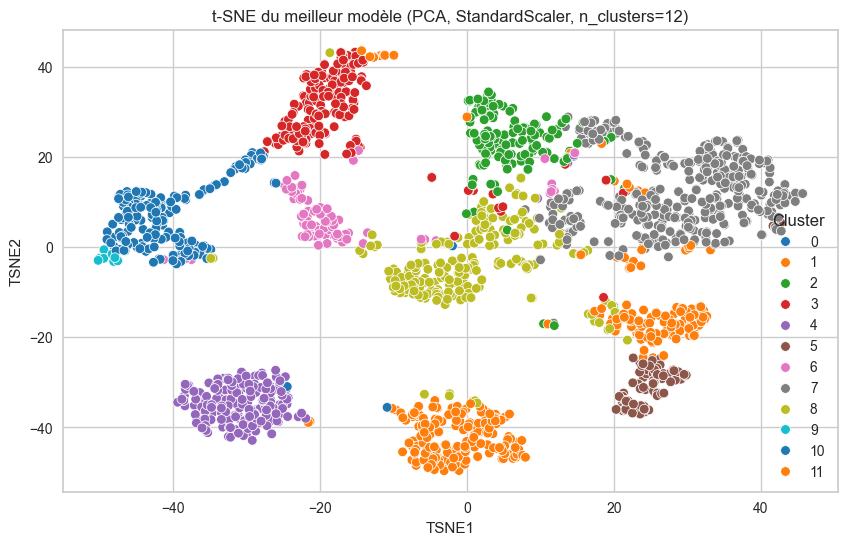


Analyse des personas :

Persona 0 :
Chiffres dominants : [7, 4, 9] (comptes : [17, 9, 4])
Proportions : [56.67, 30.0, 13.33]%
Composantes PCA clés : PC5, PC2, PC1
Valeurs du centroïde : [6.92, 5.93, -5.37]

Persona 1 :
Chiffres dominants : [6, 5, 0] (comptes : [174, 3, 2])
Proportions : [96.67, 1.67, 1.11]%
Composantes PCA clés : PC2, PC8, PC1
Valeurs du centroïde : [-3.9, -1.86, -1.27]

Persona 2 :
Chiffres dominants : [5, 8, 3] (comptes : [129, 8, 3])
Proportions : [88.97, 5.52, 2.07]%
Composantes PCA clés : PC4, PC7, PC1
Valeurs du centroïde : [-3.06, 2.15, 1.64]

Persona 3 :
Chiffres dominants : [7, 9, 3] (comptes : [150, 10, 9])
Proportions : [81.97, 5.46, 4.92]%
Composantes PCA clés : PC2, PC7, PC6
Valeurs du centroïde : [3.49, -1.99, -1.33]

Persona 4 :
Chiffres dominants : [0, 5, 6] (comptes : [173, 2, 1])
Proportions : [97.74, 1.13, 0.56]%
Composantes PCA clés : PC3, PC2, PC4
Valeurs du centroïde : [-3.08, -1.92, -1.72]

Persona 5 :
Chiffres dominants : [2, 1, 3] (comptes : [

In [97]:
# Visualisation t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_pca_best)
tsne_df = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])
tsne_df['Cluster'] = cluster_labels
tsne_df['True Label'] = labels

plt.figure(figsize=(10, 6))
sns.scatterplot(data=tsne_df, x='TSNE1', y='TSNE2', hue='Cluster', palette='tab10', legend='full')
plt.title(f"t-SNE du meilleur modèle (PCA, {best_scaler}, n_clusters={best_n_clusters})")
plt.show()

# Description des personas
print("\nAnalyse des personas :")
for cluster in range(best_n_clusters):
    print(f"\nPersona {cluster} :")
    # Chiffres dominants
    dominant_labels = label_distribution.loc[cluster].nlargest(3)
    print(f"Chiffres dominants : {dominant_labels.index.tolist()} (comptes : {dominant_labels.values.tolist()})")
    # Proportion des chiffres dominants
    total_samples = label_distribution.loc[cluster].sum()
    proportions = (dominant_labels / total_samples * 100).round(2)
    print(f"Proportions : {proportions.values.tolist()}%")
    # Caractéristiques du centroïde
    centroid = centroids[cluster]
    top_features = np.argsort(np.abs(centroid))[-3:][::-1]  # 3 composantes PCA les plus influentes
    print(f"Composantes PCA clés : {', '.join([f'PC{i+1}' for i in top_features])}")
    print(f"Valeurs du centroïde : {centroid[top_features].round(2).tolist()}")

### Enregistrer le meilleur modele

In [100]:
import joblib  # pour sauvegarder le modèle

#  Enregistrer le meilleur modèle
joblib.dump(best_kmeans, "best_kmeans_model.pkl")
print("Modèle enregistré  'best_kmeans_model.pkl'")

Modèle enregistré  'best_kmeans_model.pkl'
